#Importing modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

#Importing pytorch modules

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import random_split

#Importing Data




In [3]:
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.94MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.6MB/s]


#Visualizing the dataset

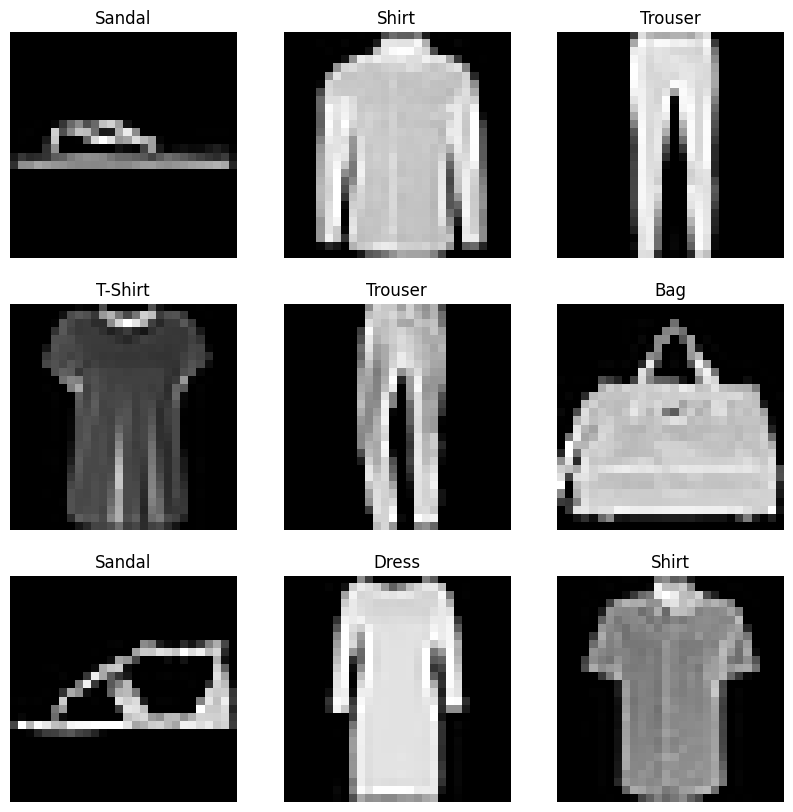

In [4]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(10, 10))
cols, rows = 3,3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

#Creating Dataloader

Shape of X [N, C, W, H]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


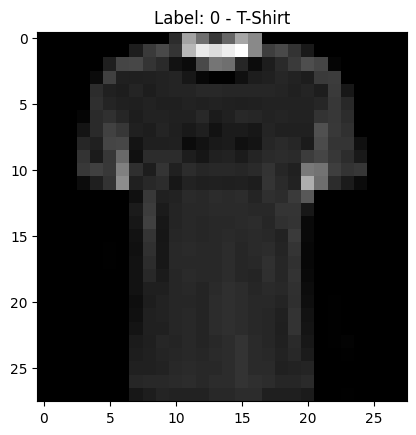

Labels batch shape : torch.Size([64])


In [5]:
#define hyperparameter
batch_size = 64

#create data loaders
train_size = int(0.9 * len(train_data))
val_size   = len(train_data) - train_size
train_subset, val_subset = random_split(train_data, [train_size, val_size])

train_dl = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_dl   = DataLoader(val_subset,   batch_size=batch_size, shuffle=False)
test_dl  = DataLoader(test_data,    batch_size=batch_size, shuffle=False)

for X,y in train_dl:
  train_features, train_labels = next(iter(train_dl))
  print(f'Shape of X [N, C, W, H]: {X.shape}')
  print(f'Shape of y: {y.shape} {y.dtype}')
  image = train_features[0].squeeze()
  label = train_labels[0]
  sample_idx = torch.randint(len(train_subset), size=(1,)).item()
  plt.title(f"Label: {label} - {labels_map[label.item()]}")
  plt.imshow(image, cmap = "gray")
  plt.show()
  print(f"Labels batch shape : {train_labels.size()}")
  break

#Creating Model




In [23]:
device = "cuda" if torch.cuda.is_available else 'cpu'
print(f'Using device {device}')

#define the model
class NeuralNet(nn.Module):
  def __init__(self):
    super(NeuralNet, self).__init__()
    self.shared = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784,16),
        nn.ReLU(),
    )
    #left branch
    self.left_fc1 = nn.Sequential(nn.Linear(16,8), nn.ReLU())
    self.left_fc2 = nn.Sequential(nn.Linear(8,8), nn.ReLU())
    #right branch
    self.right = nn.Sequential(
        nn.Linear(16, 12), nn.ReLU(),
        nn.Linear(12, 8), nn.ReLU()
    )
    #output
    self.output = nn.Linear(16, 10)

  def forward(self, x):
    shared_out = self.shared(x)

    left_skip = self.left_fc1(shared_out)
    left_out = self.left_fc2(left_skip)
    left_out = left_out + left_skip

    right_out = self.right(shared_out)

    out = torch.cat((left_out, right_out), dim=1)
    return self.output(out)
    model = NeuralNet().to(device)

Using device cuda


#Loss Function and Optimizer

In [24]:
model = NeuralNet().to(device)
#define hyperparameters
learning_rate = 1e-3
epochs = 13
#loss function
loss_fn = nn.CrossEntropyLoss()
#optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

#Model Performance
Backpropagation to update model parameters

In [25]:
def trainloop(dataloader, model, loss_fn, optimizer):
  size = len(dataloader.dataset)
  total_loss, total_correct = 0, 0
  for batch, (X,y) in enumerate(dataloader):
    X,y = X.to(device), y.to(device)
    #compute error rates
    pred = model(X)
    loss = loss_fn(pred, y)
    #backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if batch % 100 == 0:
      loss, current = loss.item(), batch * len(X)
      print(f'loss: {loss:>7f} [{current:>5d}/{size:>5d}]')
    total_loss += loss * len(X)
    total_correct += (pred.argmax(1) == y).type(torch.float).sum().item()
  return float(total_loss / size), float(total_correct / size)

Check model's performance on test data

In [26]:
def evaluate(dataloader, model, loss_fn):
  size = len(dataloader.dataset)
  num_batches = len(dataloader)
  model.eval()
  test_loss, correct = 0, 0
  with torch.no_grad():
    for X,y in dataloader:
      X,y = X.to(device), y.to(device)
      pred = model(X)
      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()
  test_loss /= num_batches
  correct /= size
  return float(test_loss), float(correct)

In [27]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for t in range(epochs):
  print(f'Epoch {t+1}')
  train_loss, train_acc = trainloop(train_dl, model, loss_fn, optimizer)
  val_loss, val_acc = evaluate(val_dl, model, loss_fn)
  train_losses.append(train_loss)
  val_losses.append(val_loss)
  train_accs.append(train_acc)
  val_accs.append(val_acc)
  print(f"Train Acc: {train_acc*100:.1f}% | Val Acc: {val_acc*100:.1f}%")

test_loss, test_acc = evaluate(test_dl, model, loss_fn)
print(f"Final Val Loss: {val_losses[-1]:.4f}")
print(f"Final Val Accuracy: {val_accs[-1]*100:.1f}%")
print('Done!')

Epoch 1
loss: 2.309108 [    0/54000]
loss: 0.999668 [ 6400/54000]
loss: 0.854250 [12800/54000]
loss: 0.807743 [19200/54000]
loss: 0.682594 [25600/54000]
loss: 0.610655 [32000/54000]
loss: 0.449074 [38400/54000]
loss: 0.625073 [44800/54000]
loss: 0.585657 [51200/54000]
Train Acc: 71.9% | Val Acc: 79.7%
Epoch 2
loss: 0.626828 [    0/54000]
loss: 0.529475 [ 6400/54000]
loss: 0.342752 [12800/54000]
loss: 0.457557 [19200/54000]
loss: 0.489873 [25600/54000]
loss: 0.348101 [32000/54000]
loss: 0.492461 [38400/54000]
loss: 0.302528 [44800/54000]
loss: 0.374135 [51200/54000]
Train Acc: 83.1% | Val Acc: 83.7%
Epoch 3
loss: 0.476079 [    0/54000]
loss: 0.462539 [ 6400/54000]
loss: 0.510472 [12800/54000]
loss: 0.694411 [19200/54000]
loss: 0.360734 [25600/54000]
loss: 0.394301 [32000/54000]
loss: 0.520306 [38400/54000]
loss: 0.500422 [44800/54000]
loss: 0.378159 [51200/54000]
Train Acc: 84.5% | Val Acc: 84.2%
Epoch 4
loss: 0.401682 [    0/54000]
loss: 0.630110 [ 6400/54000]
loss: 0.477427 [12800/540

#Saving the Model

In [28]:
torch.save(model.state_dict(), 'model_weights.pth')

#Accuracy and Loss Plots

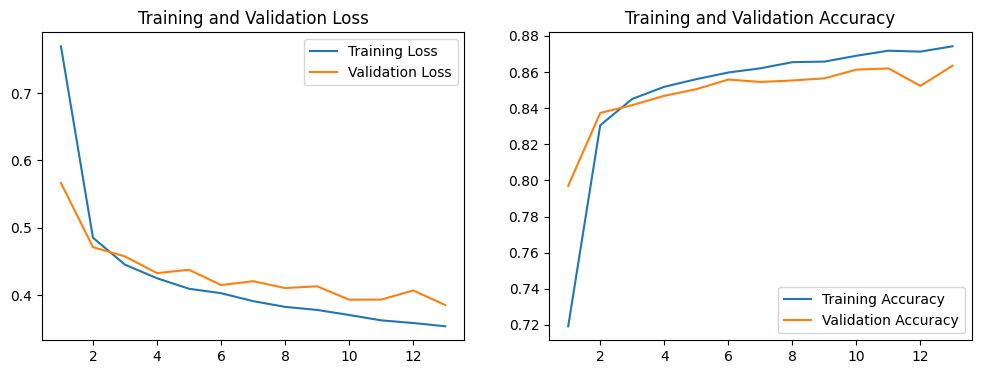

In [29]:
epochs_range = range(1, epochs+1)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.subplot(1,2,2)
plt.plot(epochs_range, train_accs, label='Training Accuracy')
plt.plot(epochs_range, val_accs, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.show()

#Generating submissions.csv

In [30]:
class_names = ["T-shirt/top",  "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

model.eval()
all_preds=[]

with torch.no_grad():
  for X, y in test_dl:
    X = X.to(device)
    pred = model(X)
    all_preds.extend(pred.argmax(1).cpu().numpy())

submission = pd.DataFrame({
    "id": range(len(all_preds)),
    "label": all_preds,
    "class": [class_names[pred] for pred in all_preds]
})
submission.to_csv("submission.csv", index=False)

Downloading model weights and submissions.csv:

In [31]:
from google.colab import files
files.download('submission.csv')
files.download('model_weights.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>